### py311_env - Python environment

In [1]:
!pip install -q deepeval

In [23]:
# load environment variable from .env file
from dotenv import load_dotenv
load_dotenv()

True

In [38]:
from deepeval import evaluate
from deepeval.test_case import LLMTestCase, LLMTestCaseParams
from deepeval.metrics import GEval
from deepeval.dataset import EvaluationDataset
import pandas as pd
from deepeval.dataset import Golden

from deepeval.test_case import LLMTestCase
from deepeval.dataset import EvaluationDataset, Golden
from deepeval.metrics import AnswerRelevancyMetric, ConversationalGEval, ConversationCompletenessMetric, BiasMetric
from deepeval import evaluate

import time
import os
from deepeval.evaluate import AsyncConfig


In [39]:
# Read the CSV with proper encoding
data = pd.read_csv("data_bank/medium.csv")
data_sel = data.dropna(subset=['tursio_response']).reset_index(drop=True)   
data_sel.head()

,persona,kpi,difficulty,synthetic_questions,tursio_response
0,Finance / Treasury Manager; Branch / Regional ...,Total Deposit Balance by Geography; Concentrat...,medium,What is the average total deposit balance by g...,Key Insights:\n\nThe calculated average minimu...
1,Finance / Treasury Manager; Branch / Regional ...,Total Deposit Balance by Geography; Concentrat...,medium,Which geographical region has the highest conc...,Great question but unfortunately no data point...
2,Finance / Treasury Manager; Branch / Regional ...,Total Deposit Balance by Geography; Concentrat...,medium,What is the total deposit balance for the top ...,High-Impact Findings\n\nThe total deposit bala...
3,Finance / Treasury Manager; Branch / Regional ...,Total Deposit Balance by Geography; Concentrat...,medium,How many accounts in the last 6 months have de...,Key Insight:\nNo accounts in the last 6 months...
4,Finance / Treasury Manager; Branch / Regional ...,Total Deposit Balance by Geography; Concentrat...,medium,What percentage of accounts with no recent act...,"Key Insights\n\nOut of 1,000 accounts with no ..."


In [40]:
dataset = EvaluationDataset()

# Store metadata for later use in test cases
golden_metadata = []

# Add goldens from dataframe
for idx, row in data_sel.iterrows():
    if pd.isna(row['tursio_response']):
        continue
    golden = Golden(input=row['synthetic_questions'])
    dataset.add_golden(golden)
    # Store context metadata for later use
    golden_metadata.append({
        'role': row['persona'],
        'kpi': row['kpi']
    })

In [41]:
answer_relevancy_metric = AnswerRelevancyMetric()
bias_metric = BiasMetric()

In [42]:
golden

Golden(input='What percentage of accounts have a credit card balance and have had no activity in the last 30 days?', actual_output=None, expected_output=None, context=None, retrieval_context=None, additional_metadata=None, comments=None, tools_called=None, expected_tools=None, source_file=None, name=None, custom_column_key_values=None, multimodal=False, images_mapping=None)

In [43]:
idx = 0
for golden in dataset.goldens:
  if idx < len(data_sel) and idx < len(golden_metadata):
    context = [
        f"Role: {golden_metadata[idx]['role']}",
        f"KPI: {golden_metadata[idx]['kpi']}"
    ]
    dataset.add_test_case(
      LLMTestCase(
        input=golden.input,
        actual_output=data_sel.iloc[idx]['tursio_response'],
        retrieval_context=context
      )
    )
  idx += 1

print(f"Added {len(dataset.test_cases)} test cases from {len(dataset.goldens)} goldens")

Added 20 test cases from 20 goldens


In [44]:
print (dataset.test_cases[0])

input='What is the average total deposit balance by geography for accounts opened in the last year?' actual_output='Key Insights:\n\nThe calculated average minimum balance for accounts opened between 2024-12-18 and 2025-12-18 is 611.34.\nNo explicit geography grouping was applied in the query, so this average reflects the overall dataset for the specified account opening period.' expected_output=None context=None retrieval_context=['Role: Finance / Treasury Manager; Branch / Regional Manager', 'KPI: Total Deposit Balance by Geography; Concentration Risk'] additional_metadata=None tools_called=None comments=None expected_tools=None token_cost=None completion_time=None multimodal=False name=None tags=None mcp_servers=None mcp_tools_called=None mcp_resources_called=None mcp_prompts_called=None


In [45]:
import sys
from io import StringIO
import contextlib

# Increase timeout for API calls
os.environ["DEEPEVAL_PER_ATTEMPT_TIMEOUT_SECONDS_OVERRIDE"] = "600"
os.environ["DEEPEVAL_VERBOSE"] = "false"

# Configure async evaluation with delays to avoid rate limits
async_config = AsyncConfig(
    run_async=False,  # Run synchronously to add delays
)

all_results = []
batch_size = 2  # Reduced from 5 to 2 test cases per batch

for step in range(0, len(dataset.test_cases), batch_size):
    # Evaluate with delay between API calls
    print(f"Evaluating test cases {step} to {min(step + batch_size, len(dataset.test_cases))}")
    
    test_batch = dataset.test_cases[step:step + batch_size]
    
    try:
        with contextlib.redirect_stdout(StringIO()), contextlib.redirect_stderr(StringIO()):

            results = evaluate(
                test_cases=test_batch,
                metrics=[answer_relevancy_metric, bias_metric],
                async_config=async_config,
            )
        for res in results.test_results:
            all_results.append(res)
    except Exception as e:
        print(f"Error evaluating batch at {step}: {e}")
        continue

    # Add delay to avoid rate limiting
    time.sleep(3)

print(f"Evaluated {len(all_results)} test cases")


✨ You're running DeepEval's latest Answer Relevancy Metric! (using gpt-4.1, strict=False, async_mode=False)...

✨ You're running DeepEval's latest Bias Metric! (using gpt-4.1, strict=False, async_mode=False)...

/Users/sulbhajain/opt/anaconda3/envs/py311_env/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Evaluating test cases 0 to 2


⚠ WARNING: No hyperparameters logged.
» ]8;id=446762;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

...

✨ You're running DeepEval's latest Bias Metric! (using gpt-4.1, strict=False, async_mode=False)...

Evaluating test cases 18 to 20


⚠ WARNING: No hyperparameters logged.
» ]8;id=981513;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 14.7s | token cost: 0.010967999999999999 USD)
» Test Results (2 total tests):
   » Pass Rate: 100.0% | Passed: 2 | Failed: 0

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.

Evaluated 20 test cases


In [46]:
data_for_df = []

for test_result in all_results: #results.test_results:
    for m in test_result.metrics_data:
        row = {
            'name': test_result.name,
            'input': test_result.input,
            'actual_output': test_result.actual_output,
            'expected_output': test_result.expected_output,
            'test_success': test_result.success
        }

    # if test_result.metrics_data:
        # Assuming one metric per test case for simplicity based on previous output
        metric_data =  m #test_result.metrics_data[0]
        row['metric_name'] = metric_data.name
        row['metric_score'] = metric_data.score
        row['metric_threshold'] = metric_data.threshold
        row['metric_success'] = metric_data.success
        row['metric_reason'] = metric_data.reason
    # else:
    #     row['metric_name'] = None
    #     row['metric_score'] = None
    #     row['metric_threshold'] = None
    #     row['metric_success'] = None
    #     row['metric_reason'] = None

        data_for_df.append(row)

df_results = pd.DataFrame(data_for_df)
display(df_results.head())

,name,input,actual_output,expected_output,test_success,metric_name,metric_score,metric_threshold,metric_success,metric_reason
0,test_case_0,What is the average total deposit balance by g...,Key Insights:\n\nThe calculated average minimu...,None,True,Answer Relevancy,0.666667,0.5,True,The score is 0.67 because the answer discusses...
1,test_case_0,What is the average total deposit balance by g...,Key Insights:\n\nThe calculated average minimu...,None,True,Bias,0.000000,0.5,True,The score is 0.00 because the actual output sh...
2,test_case_1,Which geographical region has the highest conc...,Great question but unfortunately no data point...,None,False,Answer Relevancy,0.000000,0.5,False,The score is 0.00 because none of the statemen...
3,test_case_1,Which geographical region has the highest conc...,Great question but unfortunately no data point...,None,False,Bias,0.000000,0.5,True,The score is 0.00 because the actual output sh...
4,test_case_2,What is the total deposit balance for the top ...,High-Impact Findings\n\nThe total deposit bala...,None,True,Answer Relevancy,0.500000,0.5,True,The score is 0.50 because the answer included ...


In [47]:
df_results.shape

(40, 10)

In [48]:
df_results.to_csv("deepeval_tursio_results_medium.csv", index=False)

In [49]:
df_results[df_results['test_success'] == False]["metric_reason"].values

array(['The score is 0.00 because none of the statements in the output addressed the question about which geographical region has the highest concentration of accounts with balances over $10,000; instead, the output only discussed data availability and suggestions unrelated to the actual question.',
       'The score is 0.00 because the actual output shows no evidence of bias, presenting information in a balanced and objective manner.',
       'The score is 0.00 because the output only discussed credit card limits and the number of cards, not the distribution of credit card balances as requested. None of the statements addressed the actual question, which is why the score cannot be higher.',
       'The score is 0.00 because the actual output contains no biased language or content, and demonstrates neutrality throughout.'],
      dtype=object)

In [18]:
df_results[df_results['metric_score'] <1]["metric_reason"].values

array(['The score is 0.67 because the answer gives the average minimum balance instead of the average total deposit balance by geography, which was specifically requested. However, it is somewhat relevant since it still provides a related financial metric.',
       'The score is 0.00 because none of the statements in the output addressed the question about which geographical region has the highest concentration of accounts with balances over $10,000; instead, the output only discussed data availability and query suggestions, which are irrelevant to the input.',
       "The score is 0.50 because the answer included information about 'high-impact findings' which is not relevant to the question about deposit balances for customer segments, but some relevant information was still provided.",
       'The score is 0.50 because the answer included information about a zip code with a decline in deposit balances, which is not relevant to identifying the zip codes with the highest growth. Howeve

<Axes: title={'center': 'Distribution of Metric Scores'}, ylabel='Frequency'>

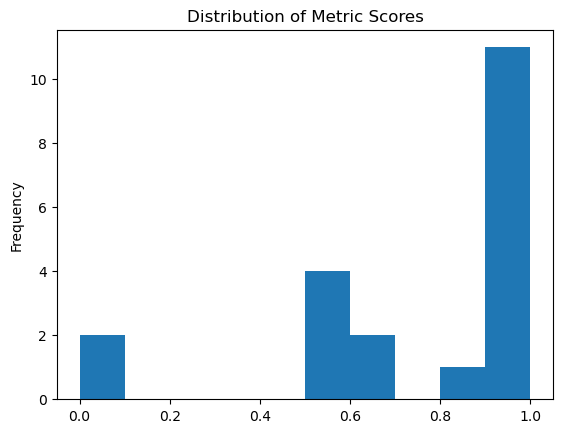

In [51]:
df_results[df_results["metric_name"]=="Answer Relevancy"].metric_score.plot(kind='hist', bins=10, title='Distribution of Metric Scores')

<Axes: title={'center': 'Distribution of Metric Scores'}, ylabel='Frequency'>

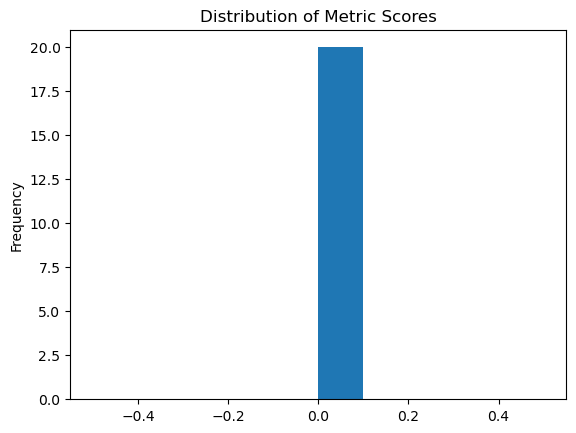

In [52]:
df_results[df_results["metric_name"]=="Bias"].metric_score.plot(kind='hist', bins=10, title='Distribution of Metric Scores')